In [1]:
# ==============================================================================
# 0. ENVIRONMENT CHECK
# ==============================================================================
import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device    : {DEVICE}')

PyTorch version : 2.5.1+cu121
CUDA available  : True
GPU             : NVIDIA GeForce RTX 4060 Laptop GPU
Using device    : cuda


In [2]:
# ==============================================================================
# 1. IMPORTS
# ==============================================================================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

try:
    from tqdm.auto import tqdm
except ImportError:
    class _NoOpTqdm:
        def __init__(self, iterable, **kwargs):
            self.iterable = iterable
        def __iter__(self):
            return iter(self.iterable)
        def set_postfix(self, *args, **kwargs):
            pass
    def tqdm(iterable, **kwargs):
        return _NoOpTqdm(iterable, **kwargs)

C:\Users\Jaswant singh\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ==============================================================================
# 2. CONFIGURATION
# ==============================================================================
class Config:
    """Central configuration — update DATA_DIR to your actual path."""
    DATA_DIR       = r'D:\amlan project\HAM10000'
    IMAGE_DIR      = os.path.join(DATA_DIR, 'images/')
    MASK_DIR       = os.path.join(DATA_DIR, 'masks/')
    METADATA_CSV   = os.path.join(DATA_DIR, 'HAM10000_metadata.csv')
    ENCODER_CKPT   = r'D:\amlan project\swinunet\swinunet_v4_encoder.pth'
    CHECKPOINT_DIR = r'D:\amlan project\Kimi phase final\checkpoints_final'

    # Backward-compatible aliases
    ENCODER_CHECKPOINT = ENCODER_CKPT
    SAVE_DIR = CHECKPOINT_DIR

    # Training
    SEED = 42
    IMG_SIZE = 224
    BATCH_SIZE = 32
    NUM_WORKERS = 0
    NUM_CLASSES = 7

    # Phase 1 (frozen encoder)
    PHASE1_EPOCHS = 10
    PHASE1_LR = 1e-3

    # Phase 2 (unfrozen encoder)
    PHASE2_EPOCHS = 50
    ENCODER_LR = 1e-5
    HEAD_LR = 5e-5

    # Early stopping
    EARLY_STOPPING_PATIENCE = 10

    # V10 Hyperparameters
    FOCAL_GAMMA = 2.0
    LAMBDA_ENTROPY = 0.1      # Entropy regularization weight
    MC_DROPOUT_T = 50         # Number of MC Dropout passes
    DROPOUT_P = 0.3           # Dropout probability (stays ON at inference)

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# ==============================================================================
# 3. REPRODUCIBILITY
# ==============================================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [5]:
# ==============================================================================
# 4. MORPHOLOGY EXTRACTION
# ==============================================================================
def extract_morphology(mask_np):
    mask_bin = (mask_np > 0.5).astype(np.uint8)
    result = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = result[0] if len(result) == 2 else result[1]

    if not contours:
        return np.zeros(5, dtype=np.float32)

    cnt = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    if area < 10 or perimeter < 1:
        return np.zeros(5, dtype=np.float32)

    asymmetry = 0.0
    if len(cnt) >= 5:
        try:
            _, axes, _ = cv2.fitEllipse(cnt)
            major = max(axes)
            minor = min(axes)
            if major > 0:
                asymmetry = 1.0 - (minor / major)
        except Exception:
            asymmetry = 0.0

    compactness = (4.0 * np.pi * area) / (perimeter ** 2 + 1e-8)
    border_irregularity = 1.0 - compactness
    color_variance = 0.0
    diameter = np.sqrt(4.0 * area / np.pi) / 224.0

    return np.array([asymmetry, border_irregularity, color_variance,
                     compactness, diameter], dtype=np.float32)


def extract_morphology_with_color(mask_np, image_np):
    features = extract_morphology(mask_np)
    mask_bin = (mask_np > 0.5).astype(np.uint8)
    if mask_bin.sum() > 0:
        masked_pixels = image_np[mask_bin > 0]
        if len(masked_pixels) > 0:
            color_std = np.std(masked_pixels, axis=0).mean()
            features[2] = color_std / 50.0
    return features

In [6]:
# ==============================================================================
# 5. DATASET (with missing-modality support)
# ==============================================================================
class HAM10000Dataset_Multimodal(Dataset):
    """
    Returns dict with keys: image, mask, morphology, metadata, availability flags, label.
    Missing modalities are returned as zero tensors plus availability=0 so DataLoader
    can collate mixed-present/mixed-missing samples.
    """
    def __init__(self, df, img_dir, mask_dir, transform=None, mode='train',
                 img_size=224, sex_map=None, site_to_idx=None,
                 missing_meta_prob=0.0, missing_morph_prob=0.0):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.mode = mode
        self.img_size = img_size
        self.sex_map = sex_map or {'male': 0.0, 'female': 1.0, 'unknown': 2.0}
        self.site_to_idx = site_to_idx or {}
        self.missing_meta_prob = missing_meta_prob
        self.missing_morph_prob = missing_morph_prob

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row['image_id']
        label = int(row['label'])

        # Load image
        img_path = os.path.join(self.img_dir, f"{img_id}.jpg")
        image = np.array(Image.open(img_path).convert("RGB"))

        # Load mask
        mask_path = os.path.join(self.mask_dir, f"{img_id}_segmentation.png")
        if not os.path.exists(mask_path):
            mask_path = os.path.join(self.mask_dir, f"{img_id}.png")
        mask = np.array(Image.open(mask_path).convert("L")) / 255.0

        # Resize
        image_resized = cv2.resize(image, (self.img_size, self.img_size))
        mask_resized = cv2.resize(mask.astype(np.float32), (self.img_size, self.img_size))

        # Extract morphology (before albumentations)
        if random.random() > self.missing_morph_prob:
            morphology = extract_morphology_with_color(mask_resized, image_resized)
            morphology = torch.tensor(morphology, dtype=torch.float32)
            morphology_available = torch.tensor(1.0, dtype=torch.float32)
        else:
            morphology = torch.zeros(5, dtype=torch.float32)
            morphology_available = torch.tensor(0.0, dtype=torch.float32)

        # Encode metadata
        if random.random() > self.missing_meta_prob:
            age = row['age'] if not pd.isna(row['age']) else 50.0
            age_norm = age / 100.0
            sex_val = self.sex_map.get(row['sex'], 2.0)
            site_val = self.site_to_idx.get(row['localization'], 0)
            metadata = torch.tensor([age_norm, sex_val, float(site_val)], dtype=torch.float32)
            metadata_available = torch.tensor(1.0, dtype=torch.float32)
        else:
            metadata = torch.zeros(3, dtype=torch.float32)
            metadata_available = torch.tensor(0.0, dtype=torch.float32)

        # Albumentations
        if self.transform:
            augmented = self.transform(image=image_resized, mask=mask_resized)
            image = augmented['image']
            mask = augmented['mask']
        else:
            image = torch.from_numpy(image_resized.transpose(2, 0, 1)).float() / 255.0
            mask = torch.from_numpy(mask_resized).float()

        if isinstance(mask, np.ndarray):
            mask = torch.from_numpy(mask).float()
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)
        elif mask.ndim == 3 and mask.shape[-1] == 1:
            mask = mask.permute(2, 0, 1)
        elif mask.ndim == 3 and mask.shape[0] != 1:
            mask = mask.unsqueeze(0)

        return {
            'image': image,
            'mask': mask,
            'morphology': morphology,
            'metadata': metadata,
            'morphology_available': morphology_available,
            'metadata_available': metadata_available,
            'label': torch.tensor(label, dtype=torch.long)
        }

In [7]:
# ==============================================================================
# 6. TRANSFORMS
# ==============================================================================
def get_transforms(img_size=224, mode='train'):
    if mode == 'train':
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.Rotate(limit=30, p=0.5),
            A.ElasticTransform(alpha=1, sigma=50, p=0.3),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
            A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
            A.GaussianBlur(blur_limit=3, p=0.3),
            A.CoarseDropout(num_holes_range=(1, 8), hole_height_range=(1, 32),
                            hole_width_range=(1, 32), fill=0, p=0.3),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])

In [8]:
# ==============================================================================
# 6.5 CUSTOM COLLATE FUNCTION (handles missing metadata/morphology)
# ==============================================================================
def custom_collate_fn(batch):
    batch = [sample for sample in batch if sample is not None]
    if not batch:
        return None

    collated = {}
    for key in batch[0].keys():
        values = [sample[key] for sample in batch]
        if any(value is None for value in values):
            collated[key] = None
        else:
            collated[key] = torch.stack(values, dim=0)

    return collated

In [9]:
# ==============================================================================
# 7. FPN
# ==============================================================================
class FeaturePyramidNetwork(nn.Module):
    def __init__(self, in_channels_list, out_channels=256):
        super().__init__()
        self.lateral_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_ch, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ) for in_ch in in_channels_list
        ])
        self.smooth_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ) for _ in in_channels_list
        ])

    def forward(self, features):
        laterals = [conv(f) for conv, f in zip(self.lateral_convs, features)]
        for i in range(len(laterals) - 1, 0, -1):
            upsampled = F.interpolate(laterals[i], size=laterals[i-1].shape[2:], mode='nearest')
            laterals[i-1] = laterals[i-1] + upsampled
        return [smooth(lat) for smooth, lat in zip(self.smooth_convs, laterals)]

In [10]:
# ==============================================================================
# 8. IMAGE ENCODER (returns pooled + spatial tokens)
# ==============================================================================
class ImageEncoderBranch(nn.Module):
    """
    Swin-B + FPN → pooled feature + spatial tokens for cross-attention
    """
    def __init__(self, encoder_checkpoint, out_dim=256):
        super().__init__()
        self.encoder = timm.create_model(
            'swin_base_patch4_window7_224',
            pretrained=False,
            features_only=True,
            out_indices=(0, 1, 2, 3)
        )
        if encoder_checkpoint and os.path.exists(encoder_checkpoint):
            ckpt = torch.load(encoder_checkpoint, map_location='cpu', weights_only=False)
            self.encoder.load_state_dict(ckpt, strict=False)

        self.fpn = FeaturePyramidNetwork([128, 256, 512, 1024], 256)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Linear(256, out_dim)

    def _to_channels_first(self, features):
        expected = [128, 256, 512, 1024]
        out = []
        for i, f in enumerate(features):
            if f.ndim == 4 and f.shape[-1] == expected[i]:
                f = f.permute(0, 3, 1, 2).contiguous()
            out.append(f)
        return out

    def forward(self, image):
        features = self._to_channels_first(self.encoder(image))
        fpn_features = self.fpn(features)

        # P2 for Grad-CAM (56x56)
        p2 = fpn_features[0]  # (B, 256, 56, 56)

        # P4 for spatial tokens (14x14 = 196 tokens)
        p4 = fpn_features[2]  # (B, 256, 14, 14)
        B, C, H, W = p4.shape
        spatial_tokens = p4.view(B, C, H * W).permute(0, 2, 1)  # (B, 196, 256)

        # Pooled feature
        pooled = self.pool(p2).flatten(1)  # (B, 256)
        pooled = self.proj(pooled)  # (B, 256)

        return pooled, spatial_tokens, p2  # p2 for Grad-CAM target

In [11]:
# ==============================================================================
# 9. MODALITY ENCODERS
# ==============================================================================
class MetadataEncoder(nn.Module):
    def __init__(self, num_sites, embed_dim=16, out_dim=256):
        super().__init__()
        self.site_embed = nn.Embedding(num_sites, embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(1 + 1 + embed_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(128, out_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, metadata):
        age = metadata[:, 0:1]
        sex = metadata[:, 1:2]
        site = metadata[:, 2].long()
        site_vec = self.site_embed(site)
        x = torch.cat([age, sex, site_vec], dim=1)
        return self.mlp(x)


class MorphologyEncoder(nn.Module):
    def __init__(self, in_dim=5, out_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(64, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(128, out_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, morphology):
        return self.mlp(morphology)

In [12]:
# ==============================================================================
# 10. BILATERAL CROSS-MODAL ATTENTION FUSION (CORRECTED)
# ==============================================================================
class CrossModalAttentionBlock(nn.Module):
    """
    Query from one modality attends to spatial tokens from image.
    This creates MEANINGFUL attention (query: Bx1x256, KV: Bx196x256)
    """
    def __init__(self, dim=256, num_heads=8, dropout=0.1):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.norm = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(dim * 2, dim),
            nn.Dropout(dropout)
        )
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, query, kv):
        """
        query: (B, 1, D) - pooled modality feature
        kv:    (B, N, D) - spatial tokens from image (N=196)
        """
        attn_out, attn_weights = self.cross_attn(query, kv, kv)
        out = self.norm(query + attn_out)
        out = self.norm2(out + self.ffn(out))
        return out, attn_weights


class BCMAF(nn.Module):
    """
    Bilateral Cross-Modal Attention Fusion (CORRECTED)
    All modalities attend to IMAGE SPATIAL TOKENS
    """
    def __init__(self, dim=256, num_heads=8, dropout=0.1):
        super().__init__()

        # All blocks attend to image spatial tokens
        self.img_self_attn = CrossModalAttentionBlock(dim, num_heads, dropout)
        self.meta_to_img = CrossModalAttentionBlock(dim, num_heads, dropout)
        self.morph_to_img = CrossModalAttentionBlock(dim, num_heads, dropout)

        # Projection for enriched features
        self.img_proj = nn.Linear(dim, dim)
        self.meta_proj = nn.Linear(dim, dim)
        self.morph_proj = nn.Linear(dim, dim)

    def forward(self, img_pooled, img_spatial, meta_feat, morph_feat):
        """
        img_pooled:   (B, 256)
        img_spatial:  (B, 196, 256)
        meta_feat:    (B, 256)
        morph_feat:   (B, 256)
        """
        # Add sequence dimension
        img_q = img_pooled.unsqueeze(1)    # (B, 1, 256)
        meta_q = meta_feat.unsqueeze(1)    # (B, 1, 256)
        morph_q = morph_feat.unsqueeze(1)  # (B, 1, 256)

        # Block A: Image self-attention on spatial tokens
        img_enriched, attn_img = self.img_self_attn(img_q, img_spatial)

        # Block B: Metadata attends to image spatial tokens
        meta_enriched, attn_meta = self.meta_to_img(meta_q, img_spatial)

        # Block C: Morphology attends to image spatial tokens
        morph_enriched, attn_morph = self.morph_to_img(morph_q, img_spatial)

        # Project
        img_enriched = self.img_proj(img_enriched.squeeze(1))
        meta_enriched = self.meta_proj(meta_enriched.squeeze(1))
        morph_enriched = self.morph_proj(morph_enriched.squeeze(1))

        # Collect attention weights for TMEP (upsample from 196 to 14x14)
        attention_weights = {
            'img': attn_img.view(-1, 14, 14),      # (B, 14, 14)
            'meta': attn_meta.view(-1, 14, 14),    # (B, 14, 14)
            'morph': attn_morph.view(-1, 14, 14)   # (B, 14, 14)
        }

        return img_enriched, meta_enriched, morph_enriched, attention_weights

In [13]:
# ==============================================================================
# 11. ENTROPY-REGULARIZED 3-WAY GATING
# ==============================================================================
class GatingNetwork(nn.Module):
    """
    Computes 3-way gating weights with entropy regularization.
    """
    def __init__(self, dim=256, num_modalities=3):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(dim * num_modalities, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_modalities)
        )

    def forward(self, img_enriched, meta_enriched, morph_enriched):
        concat = torch.cat([img_enriched, meta_enriched, morph_enriched], dim=1)
        logits = self.mlp(concat)  # (B, 3)
        gates = F.softmax(logits, dim=1)  # (B, 3), sum=1

        # Entropy regularization: maximize entropy = minimize negative entropy
        eps = 1e-6
        entropy = -(gates * torch.log(gates + eps)).sum(dim=1).mean()
        entropy_loss = -entropy  # Negative because we minimize total loss

        # Fused representation
        fused = (gates[:, 0:1] * img_enriched +
                 gates[:, 1:2] * meta_enriched +
                 gates[:, 2:3] * morph_enriched)

        return fused, gates, entropy_loss

In [14]:
# ==============================================================================
# 12. MC DROPOUT CLASSIFIER
# ==============================================================================
class MCDropoutClassifier(nn.Module):
    """
    Classifier with dropout that STAYS ON at inference.
    """
    def __init__(self, in_dim=256, hidden_dim=256, num_classes=7, dropout_p=0.3):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout_p)  # Always active
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)  # Active in both train AND eval
        return self.fc2(x)

In [15]:
# ==============================================================================
# 13. LOSS FUNCTIONS
# ==============================================================================
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super().__init__()
        if weight is not None:
            self.register_buffer('weight', weight)
        else:
            self.weight = None
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, reduction='none', weight=self.weight)
        pt = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        if self.reduction == 'mean':
            return focal.mean()
        return focal


class CombinedLoss(nn.Module):
    def __init__(self, class_weights=None, gamma=2.0, lambda_entropy=0.1):
        super().__init__()
        self.focal = FocalLoss(weight=class_weights, gamma=gamma)
        self.lambda_entropy = lambda_entropy

    def forward(self, logits, labels, entropy_loss):
        loss_cls = self.focal(logits, labels)
        loss_total = loss_cls + self.lambda_entropy * entropy_loss
        return loss_total, {
            'loss_total': loss_total.item(),
            'loss_cls': loss_cls.item(),
            'loss_entropy': entropy_loss.item()
        }

In [16]:
# ==============================================================================
# 14. X-MMFNet FINAL MODEL (CORRECTED)
# ==============================================================================
class X_MMFNet(nn.Module):
    def __init__(self, num_classes=7, pretrained=True,
                 encoder_checkpoint="swinunet_v4_encoder.pth",
                 num_sites=15, dropout_p=0.3):
        super().__init__()

        # Modality encoders
        self.image_branch = ImageEncoderBranch(encoder_checkpoint, out_dim=256)
        self.metadata_encoder = MetadataEncoder(num_sites=num_sites, out_dim=256)
        self.morphology_encoder = MorphologyEncoder(in_dim=5, out_dim=256)

        # BCMAF
        self.bcmaf = BCMAF(dim=256, num_heads=8, dropout=0.1)

        # Gating Network
        self.gating = GatingNetwork(dim=256, num_modalities=3)

        # MC Dropout Classifier
        self.classifier = MCDropoutClassifier(
            in_dim=256, hidden_dim=256, num_classes=num_classes, dropout_p=dropout_p
        )

        # Store for TMEP
        self.last_attention_weights = None
        self.last_gates = None

    def forward(self, image, metadata=None, morphology=None,
                metadata_available=None, morphology_available=None):
        B = image.size(0)

        # Encode image → pooled + spatial tokens
        img_pooled, img_spatial, p2 = self.image_branch(image)
        # img_pooled: (B, 256), img_spatial: (B, 196, 256), p2: (B, 256, 56, 56)

        # Encode metadata
        if metadata is not None:
            meta_feat = self.metadata_encoder(metadata)  # (B, 256)
            if metadata_available is not None:
                meta_feat = meta_feat * metadata_available.to(image.device).view(B, 1)
        else:
            meta_feat = torch.zeros(B, 256, device=image.device)

        # Encode morphology
        if morphology is not None:
            morph_feat = self.morphology_encoder(morphology)  # (B, 256)
            if morphology_available is not None:
                morph_feat = morph_feat * morphology_available.to(image.device).view(B, 1)
        else:
            morph_feat = torch.zeros(B, 256, device=image.device)

        # BCMAF: All modalities attend to image spatial tokens
        img_enriched, meta_enriched, morph_enriched, attn_weights = self.bcmaf(
            img_pooled, img_spatial, meta_feat, morph_feat
        )

        # Gating with entropy regularization
        fused, gates, entropy_loss = self.gating(img_enriched, meta_enriched, morph_enriched)

        # Classification
        logits = self.classifier(fused)

        # Store for TMEP
        self.last_attention_weights = attn_weights
        self.last_gates = gates.detach()

        return logits, entropy_loss, gates, p2

    @torch.no_grad()
    def predict_with_uncertainty(self, image, metadata=None, morphology=None,
                                 metadata_available=None, morphology_available=None, T=50):
        self.train()  # Keep dropout ON
        logits_list = []
        for _ in range(T):
            logits, _, _, _ = self.forward(
                image, metadata, morphology, metadata_available, morphology_available)
            logits_list.append(logits)

        logits_stack = torch.stack(logits_list, dim=0)  # (T, B, C)
        mean_logits = logits_stack.mean(dim=0)  # (B, C)
        variance = logits_stack.var(dim=0)      # (B, C)

        probs = F.softmax(mean_logits, dim=1)
        entropy = -(probs * torch.log(probs + 1e-10)).sum(dim=1)  # (B,)

        return mean_logits, variance, entropy

In [17]:
# ==============================================================================
# 15. TMEP: TRI-MODAL EXPLAINABILITY PIPELINE
# ==============================================================================
class GradCAMPP:
    """
    Grad-CAM++ for visual explainability
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, image, metadata=None, morphology=None,
                 metadata_available=None, morphology_available=None, target_class=None):
        self.model.zero_grad()
        logits, _, _, _ = self.model(
            image, metadata, morphology, metadata_available, morphology_available)
        if target_class is None:
            target_class = logits.argmax(dim=1)

        one_hot = torch.zeros_like(logits)
        one_hot.scatter_(1, target_class.unsqueeze(1), 1.0)

        logits.backward(gradient=one_hot, retain_graph=True)

        grads = self.gradients  # (B, C, H, W)
        acts = self.activations  # (B, C, H, W)

        # Grad-CAM++ weights
        grads_power_2 = grads ** 2
        alpha_num = grads_power_2
        alpha_denom = 2 * grads_power_2 + (acts * grads ** 3).sum(dim=(2, 3), keepdim=True)
        alpha_denom = torch.where(alpha_denom != 0.0, alpha_denom, torch.ones_like(alpha_denom))
        alpha = alpha_num / alpha_denom

        weights = (alpha * F.relu(grads)).sum(dim=(2, 3))  # (B, C)

        cam = torch.zeros(acts.size(0), acts.size(2), acts.size(3), device=acts.device)
        for i in range(weights.size(1)):
            cam += weights[:, i:i+1] * acts[:, i, :, :]

        cam = F.relu(cam)
        cam = cam - cam.min(dim=1, keepdim=True)[0].min(dim=2, keepdim=True)[0]
        cam = cam / (cam.max(dim=1, keepdim=True)[0].max(dim=2, keepdim=True)[0] + 1e-8)
        return cam


def compute_mas(gradcam_heatmap, seg_mask):
    """
    Mask-Alignment Score = saliency_inside / total_saliency
    """
    heatmap = F.relu(gradcam_heatmap)
    heatmap_sum = heatmap.sum(dim=(1, 2), keepdim=True) + 1e-8
    heatmap = heatmap / heatmap_sum

    mask_bin = (seg_mask > 0.5).float()

    inside = (heatmap * mask_bin).sum(dim=(1, 2))
    total = heatmap.sum(dim=(1, 2))
    mas = inside / (total + 1e-8)

    return mas


def shap_metadata_summary(metadata_values, feature_names=['age', 'sex', 'site']):
    contributions = torch.abs(metadata_values).mean(dim=0)
    return dict(zip(feature_names, contributions.tolist()))


def plot_modality_contribution(gates, save_path):
    mean_gates = gates.mean(dim=0).cpu().numpy()
    labels = ['Image', 'Metadata', 'Morphology']
    colors = ['#ff9999', '#66b3ff', '#99ff99']

    plt.figure(figsize=(8, 6))
    plt.pie(mean_gates, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    plt.title('Modality Contribution (Gating Weights)')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved modality contribution chart to {save_path}")


def generate_tmep_dashboard(model, batch, config, save_dir):
    model.eval()
    images = batch['image'].to(config.DEVICE)
    masks = batch['mask'].to(config.DEVICE)

    metadata = batch.get('metadata')
    if metadata is not None:
        metadata = metadata.to(config.DEVICE)
    metadata_available = batch.get('metadata_available')
    if metadata_available is not None:
        metadata_available = metadata_available.to(config.DEVICE)

    morphology = batch.get('morphology')
    if morphology is not None:
        morphology = morphology.to(config.DEVICE)
    morphology_available = batch.get('morphology_available')
    if morphology_available is not None:
        morphology_available = morphology_available.to(config.DEVICE)

    with torch.no_grad():
        logits, _, gates, p2 = model(
            images, metadata, morphology, metadata_available, morphology_available)

    # Grad-CAM++ on P2 (56x56) - target the first conv in FPN
    target_layer = model.image_branch.fpn.lateral_convs[0][0]  # Conv2d inside Sequential
    gradcam = GradCAMPP(model, target_layer)
    heatmaps = gradcam.generate(
        images, metadata, morphology, metadata_available, morphology_available)

    # Compute MAS
    masks_resized = F.interpolate(masks, size=heatmaps.shape[1:], mode='nearest')
    mas = compute_mas(heatmaps, masks_resized.squeeze(1))

    # Modality contribution
    plot_modality_contribution(gates, os.path.join(save_dir, 'modality_contribution.png'))

    # Visualize
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    img_np = images[0].cpu().permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1)

    axes[0, 0].imshow(img_np)
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(img_np)
    mask_np = masks[0, 0].cpu().numpy()
    axes[0, 1].imshow(mask_np, alpha=0.5, cmap='jet')
    axes[0, 1].set_title(f'Segmentation (MAS={mas[0]:.3f})')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(img_np)
    heatmap_np = heatmaps[0].cpu().numpy()
    heatmap_up = cv2.resize(heatmap_np, (config.IMG_SIZE, config.IMG_SIZE))
    axes[0, 2].imshow(heatmap_up, alpha=0.6, cmap='hot')
    axes[0, 2].set_title('Grad-CAM++')
    axes[0, 2].axis('off')

    if metadata is not None:
        shap_vals = shap_metadata_summary(metadata)
        axes[1, 0].bar(shap_vals.keys(), shap_vals.values())
        axes[1, 0].set_title('Metadata Attribution')
        axes[1, 0].tick_params(axis='x', rotation=45)
    else:
        axes[1, 0].text(0.5, 0.5, 'Metadata Missing', ha='center', va='center')
        axes[1, 0].set_title('Metadata Attribution')

    gates_np = gates[0].cpu().numpy()
    axes[1, 1].bar(['Image', 'Metadata', 'Morphology'], gates_np)
    axes[1, 1].set_title('Modality Gating')
    axes[1, 1].set_ylim(0, 1)

    probs = F.softmax(logits[0], dim=0)
    top5 = torch.topk(probs, 5)
    axes[1, 2].barh(range(5), top5.values.cpu().numpy())
    axes[1, 2].set_yticks(range(5))
    axes[1, 2].set_yticklabels([f'Class {i}' for i in top5.indices.cpu().numpy()])
    axes[1, 2].set_title('Top-5 Predictions')
    axes[1, 2].set_xlim(0, 1)

    plt.tight_layout()
    save_path = os.path.join(save_dir, 'tmep_dashboard.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved TMEP dashboard to {save_path}")

    return {'mas': mas.mean().item(), 'gates': gates.mean(dim=0).cpu().numpy()}

In [18]:
# ==============================================================================
# 16. ECE CALIBRATION METRIC
# ==============================================================================
def compute_ece(probs, labels, n_bins=15):
    bin_boundaries = torch.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    confidences, predictions = probs.max(dim=1)
    accuracies = (predictions == labels).float()

    ece = 0.0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = in_bin.float().mean()

        if prop_in_bin > 0:
            accuracy_in_bin = accuracies[in_bin].mean()
            avg_confidence_in_bin = confidences[in_bin].mean()
            ece += torch.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

    return ece.item()

In [19]:
# ==============================================================================
# 17. CLASS WEIGHTS
# ==============================================================================
def get_class_weights(df):
    counts = df['label'].value_counts().sort_index().values
    weights = 1.0 / np.sqrt(counts)
    weights = weights / weights.sum() * len(weights)
    return torch.tensor(weights, dtype=torch.float32)

In [20]:
# ==============================================================================
# 18. TRAINER (CORRECTED None HANDLING)
# ==============================================================================
class Trainer:
    def __init__(self, model, config, save_dir):
        self.model = model.to(config.DEVICE)
        self.config = config
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)

        self.history = {
            'phase': [], 'epoch': [],
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [],
            'train_f1': [], 'val_f1': [],
            'gate_entropy': [], 'val_gate_entropy': []
        }

    def _get_optimizer(self, phase='phase1'):
        if phase == 'phase1':
            for p in self.model.image_branch.encoder.parameters():
                p.requires_grad = False

            params = [
                {'params': self.model.image_branch.fpn.parameters()},
                {'params': self.model.metadata_encoder.parameters()},
                {'params': self.model.morphology_encoder.parameters()},
                {'params': self.model.bcmaf.parameters()},
                {'params': self.model.gating.parameters()},
                {'params': self.model.classifier.parameters()}
            ]
            return torch.optim.AdamW(params, lr=self.config.PHASE1_LR, weight_decay=1e-4)

        if phase == 'phase2':
            for p in self.model.image_branch.encoder.parameters():
                p.requires_grad = True

            params = [
                {'params': self.model.image_branch.encoder.parameters(), 'lr': self.config.ENCODER_LR},
                {'params': self.model.image_branch.fpn.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.metadata_encoder.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.morphology_encoder.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.bcmaf.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.gating.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.classifier.parameters(), 'lr': self.config.HEAD_LR}
            ]
            return torch.optim.AdamW(params, weight_decay=1e-4)

        raise ValueError("phase must be 'phase1' or 'phase2'")

    def _num_epochs(self, phase):
        return self.config.PHASE1_EPOCHS if phase == 'phase1' else self.config.PHASE2_EPOCHS

    def _phase_name(self, phase):
        return 'PHASE 1: Frozen encoder' if phase == 'phase1' else 'PHASE 2: Unfrozen encoder'

    def _checkpoint_path(self, phase):
        return os.path.join(self.save_dir, f'{phase}_latest.pth')

    def _best_model_path(self):
        return os.path.join(self.save_dir, 'best_model.pth')

    def _load_best_score(self):
        path = self._best_model_path()
        if not os.path.exists(path):
            return 0.0
        ckpt = torch.load(path, map_location=self.config.DEVICE, weights_only=False)
        return ckpt.get('best_val_f1', ckpt.get('val_f1', 0.0))

    def _save_checkpoint(self, phase, epoch, optimizer, scheduler, best_val_f1, patience_counter):
        ckpt = {
            'phase': phase,
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
            'history': self.history,
            'best_val_f1': best_val_f1,
            'patience_counter': patience_counter,
        }
        torch.save(ckpt, self._checkpoint_path(phase))

    def _resume_phase(self, phase, optimizer, scheduler, resume=True):
        best_val_f1 = self._load_best_score()
        patience_counter = 0
        start_epoch = 0

        if not resume:
            return start_epoch, best_val_f1, patience_counter

        ckpt_path = self._checkpoint_path(phase)
        if os.path.exists(ckpt_path):
            ckpt = torch.load(ckpt_path, map_location=self.config.DEVICE, weights_only=False)
            self.model.load_state_dict(ckpt['model_state_dict'])
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
            if scheduler is not None and ckpt.get('scheduler_state_dict') is not None:
                scheduler.load_state_dict(ckpt['scheduler_state_dict'])
            self.history = ckpt.get('history', self.history)
            best_val_f1 = ckpt.get('best_val_f1', best_val_f1)
            patience_counter = ckpt.get('patience_counter', 0)
            start_epoch = ckpt['epoch'] + 1
            print(f"Resuming {phase} from epoch {start_epoch + 1}")
            return start_epoch, best_val_f1, patience_counter

        best_path = self._best_model_path()
        if phase == 'phase2' and os.path.exists(best_path):
            ckpt = torch.load(best_path, map_location=self.config.DEVICE, weights_only=False)
            self.model.load_state_dict(ckpt['model_state_dict'])
            self.history = ckpt.get('history', self.history)
            best_val_f1 = ckpt.get('best_val_f1', ckpt.get('val_f1', best_val_f1))
            print(f"Loaded best model before phase2 (val F1: {best_val_f1:.4f})")

        return start_epoch, best_val_f1, patience_counter

    def train_epoch(self, loader, criterion, optimizer, scheduler, epoch, total_epochs, phase):
        self.model.train()
        total_loss = 0
        all_preds, all_labels = [], []
        gate_entropies = []

        progress = tqdm(loader, desc=f"{phase} epoch {epoch + 1}/{total_epochs}", leave=False)
        for batch_idx, batch in enumerate(progress):
            images = batch['image'].to(self.config.DEVICE)
            masks = batch['mask'].to(self.config.DEVICE)
            labels = batch['label'].to(self.config.DEVICE)

            metadata = batch.get('metadata')
            if metadata is not None:
                metadata = metadata.to(self.config.DEVICE)
            metadata_available = batch.get('metadata_available')
            if metadata_available is not None:
                metadata_available = metadata_available.to(self.config.DEVICE)

            morphology = batch.get('morphology')
            if morphology is not None:
                morphology = morphology.to(self.config.DEVICE)
            morphology_available = batch.get('morphology_available')
            if morphology_available is not None:
                morphology_available = morphology_available.to(self.config.DEVICE)

            # Random missing modality augmentation during training
            if self.model.training and random.random() < 0.1:
                if metadata_available is not None:
                    metadata_available = torch.zeros_like(metadata_available)
                else:
                    metadata = None
            if self.model.training and random.random() < 0.1:
                if morphology_available is not None:
                    morphology_available = torch.zeros_like(morphology_available)
                else:
                    morphology = None

            optimizer.zero_grad()
            logits, entropy_loss, gates, _ = self.model(
                images, metadata, morphology, metadata_available, morphology_available)
            loss, loss_dict = criterion(logits, labels, entropy_loss)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            gate_probs = gates + 1e-8
            gate_ent = -(gate_probs * torch.log(gate_probs)).sum(dim=1).mean()
            gate_entropies.append(gate_ent.item())

            progress.set_postfix({
                'loss': f"{total_loss / (batch_idx + 1):.4f}",
                'ent': f"{gate_ent:.3f}"
            })

        if scheduler is not None:
            scheduler.step()

        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='macro')
        avg_gate_entropy = np.mean(gate_entropies)

        return total_loss / len(loader), acc, f1, avg_gate_entropy

    @torch.no_grad()
    def evaluate(self, loader, criterion, desc='Validation'):
        self.model.eval()
        total_loss = 0
        all_preds, all_labels, all_probs, gate_entropies = [], [], [], []

        for batch in tqdm(loader, desc=desc, leave=False):
            images = batch['image'].to(self.config.DEVICE)
            masks = batch['mask'].to(self.config.DEVICE)
            labels = batch['label'].to(self.config.DEVICE)

            metadata = batch.get('metadata')
            if metadata is not None:
                metadata = metadata.to(self.config.DEVICE)
            metadata_available = batch.get('metadata_available')
            if metadata_available is not None:
                metadata_available = metadata_available.to(self.config.DEVICE)

            morphology = batch.get('morphology')
            if morphology is not None:
                morphology = morphology.to(self.config.DEVICE)
            morphology_available = batch.get('morphology_available')
            if morphology_available is not None:
                morphology_available = morphology_available.to(self.config.DEVICE)

            logits, entropy_loss, gates, _ = self.model(
                images, metadata, morphology, metadata_available, morphology_available)
            loss, _ = criterion(logits, labels, entropy_loss)
            total_loss += loss.item()

            probs = F.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            gate_probs = gates + 1e-8
            gate_ent = -(gate_probs * torch.log(gate_probs)).sum(dim=1).mean()
            gate_entropies.append(gate_ent.item())

        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='macro')
        try:
            auc = roc_auc_score(
                np.eye(self.config.NUM_CLASSES)[all_labels],
                np.array(all_probs),
                average='macro', multi_class='ovr'
            )
        except Exception:
            auc = 0.0

        all_probs_tensor = torch.tensor(np.array(all_probs))
        all_labels_tensor = torch.tensor(all_labels)
        ece = compute_ece(all_probs_tensor, all_labels_tensor)

        return total_loss / len(loader), acc, f1, auc, np.mean(gate_entropies), ece

    def fit_phase(self, phase, train_loader, val_loader, class_weights, resume=True):
        if phase not in {'phase1', 'phase2'}:
            raise ValueError("phase must be 'phase1' or 'phase2'")

        total_epochs = self._num_epochs(phase)
        criterion = CombinedLoss(
            class_weights=class_weights.to(self.config.DEVICE),
            gamma=self.config.FOCAL_GAMMA,
            lambda_entropy=self.config.LAMBDA_ENTROPY
        )
        optimizer = self._get_optimizer(phase)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

        start_epoch, best_val_f1, patience_counter = self._resume_phase(phase, optimizer, scheduler, resume)

        print("\n" + "="*60)
        print(self._phase_name(phase))
        print("="*60)

        if start_epoch >= total_epochs:
            print(f"{phase} already complete.")
            print(f"Best validation F1: {best_val_f1:.4f}")
            return

        epoch_progress = tqdm(range(start_epoch, total_epochs), desc=f"{phase} epochs",
                              total=total_epochs, initial=start_epoch)
        for epoch in epoch_progress:
            train_loss, train_acc, train_f1, train_gate_ent = self.train_epoch(
                train_loader, criterion, optimizer, scheduler, epoch, total_epochs, phase)
            val_loss, val_acc, val_f1, val_auc, val_gate_ent, val_ece = self.evaluate(
                val_loader, criterion, desc=f"{phase} validation {epoch + 1}/{total_epochs}")

            epoch_progress.set_postfix({
                'train_loss': f"{train_loss:.4f}",
                'train_f1': f"{train_f1:.4f}",
                'val_loss': f"{val_loss:.4f}",
                'val_f1': f"{val_f1:.4f}",
                'best_f1': f"{max(best_val_f1, val_f1):.4f}",
                'gate_ent': f"{val_gate_ent:.3f}",
                'ece': f"{val_ece:.4f}"
            })

            print(f"Epoch {epoch+1}/{total_epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} F1: {train_f1:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f} AUC: {val_auc:.4f} | "
                  f"Gate Ent: {val_gate_ent:.3f} ECE: {val_ece:.4f}")

            for k, v in zip(['phase', 'epoch', 'train_loss', 'val_loss',
                             'train_acc', 'val_acc', 'train_f1', 'val_f1', 'gate_entropy'],
                            [phase, epoch + 1, train_loss, val_loss,
                             train_acc, val_acc, train_f1, val_f1, val_gate_ent]):
                self.history[k].append(v)

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                patience_counter = 0
                torch.save({
                    'phase': phase, 'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
                    'history': self.history,
                    'val_f1': val_f1, 'best_val_f1': best_val_f1,
                }, self._best_model_path())
                print(f"  -> Saved best model (val F1: {val_f1:.4f})")
            else:
                patience_counter += 1

            self._save_checkpoint(phase, epoch, optimizer, scheduler, best_val_f1, patience_counter)
            print(f"  -> Saved checkpoint: {self._checkpoint_path(phase)}")

            if phase == 'phase2' and patience_counter >= self.config.EARLY_STOPPING_PATIENCE:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

        print(f"\nBest validation F1: {best_val_f1:.4f}")

    def fit(self, train_loader, val_loader, class_weights, resume=True):
        self.fit_phase('phase1', train_loader, val_loader, class_weights, resume=resume)
        self.fit_phase('phase2', train_loader, val_loader, class_weights, resume=resume)

    def plot_history(self):
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes[0, 0].plot(self.history['train_loss'], label='Train')
        axes[0, 0].plot(self.history['val_loss'], label='Val')
        axes[0, 0].set_title('Loss'); axes[0, 0].legend()

        axes[0, 1].plot(self.history['train_acc'], label='Train')
        axes[0, 1].plot(self.history['val_acc'], label='Val')
        axes[0, 1].set_title('Accuracy'); axes[0, 1].legend()

        axes[0, 2].plot(self.history['train_f1'], label='Train')
        axes[0, 2].plot(self.history['val_f1'], label='Val')
        axes[0, 2].set_title('Macro F1'); axes[0, 2].legend()

        axes[1, 0].plot(self.history['gate_entropy'])
        axes[1, 0].set_title('Gate Entropy (Higher=More Balanced)')

        axes[1, 1].axis('off')
        axes[1, 2].axis('off')

        plt.tight_layout()
        plt.savefig(os.path.join(self.save_dir, 'training_curves.png'))
        plt.show()

In [21]:
# ==============================================================================
# 19. EVALUATION WITH UNCERTAINTY & TMEP
# ==============================================================================
def evaluate_model(model, test_loader, config, save_dir):
    model.train()  # Keep dropout ON for MC Dropout
    all_preds, all_labels, all_probs = [], [], []
    all_entropies, all_variances = [], []

    with torch.no_grad():
        for batch in test_loader:
            images = batch['image'].to(config.DEVICE)
            masks = batch['mask'].to(config.DEVICE)
            labels = batch['label'].to(config.DEVICE)

            metadata = batch.get('metadata')
            if metadata is not None:
                metadata = metadata.to(config.DEVICE)
            metadata_available = batch.get('metadata_available')
            if metadata_available is not None:
                metadata_available = metadata_available.to(config.DEVICE)

            morphology = batch.get('morphology')
            if morphology is not None:
                morphology = morphology.to(config.DEVICE)
            morphology_available = batch.get('morphology_available')
            if morphology_available is not None:
                morphology_available = morphology_available.to(config.DEVICE)

            mean_logits, variance, entropy = model.predict_with_uncertainty(
                images, metadata, morphology, metadata_available, morphology_available,
                T=config.MC_DROPOUT_T)

            probs = F.softmax(mean_logits, dim=1)
            preds = mean_logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_entropies.extend(entropy.cpu().numpy())
            all_variances.extend(variance.mean(dim=1).cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')

    try:
        auc_macro = roc_auc_score(
            np.eye(config.NUM_CLASSES)[all_labels],
            np.array(all_probs),
            average='macro', multi_class='ovr'
        )
    except Exception:
        auc_macro = 0.0

    report = classification_report(
        all_labels, all_preds,
        target_names=['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'],
        output_dict=True
    )

    cm = confusion_matrix(all_labels, all_preds)

    all_probs_tensor = torch.tensor(np.array(all_probs))
    all_labels_tensor = torch.tensor(all_labels)
    ece = compute_ece(all_probs_tensor, all_labels_tensor)

    high_uncertainty = np.sum(np.array(all_entropies) > np.log(config.NUM_CLASSES) * 0.5)
    uncertainty_rate = high_uncertainty / len(all_entropies)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'],
                yticklabels=['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'])
    plt.title(f'Confusion Matrix - X-MMFNet (ECE={ece:.4f})')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'confusion_matrix.png'))
    plt.show()

    print("\n" + "="*60)
    print("X-MMFNet FINAL TEST RESULTS")
    print("="*60)
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1_macro:.4f}")
    print(f"Weighted F1: {f1_weighted:.4f}")
    print(f"Macro AUC: {auc_macro:.4f}")
    print(f"ECE: {ece:.4f} (Target < 0.05)")
    print(f"Mean Uncertainty Entropy: {np.mean(all_entropies):.4f}")
    print(f"High Uncertainty Rate: {uncertainty_rate:.2%} (flagged for review)")
    print("\nPer-class metrics:")
    for cls in ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']:
        print(f"  {cls:6s}: Precision={report[cls]['precision']:.4f}, "
              f"Recall={report[cls]['recall']:.4f}, F1={report[cls]['f1-score']:.4f}")

    print(f"\nTarget (beat V4-C): Accuracy >= 0.835, Macro F1 >= 0.733")
    if f1_macro > 0.733:
        print("SUCCESS: Beat V4-C baseline!")
    else:
        print("NEEDS IMPROVEMENT")

    # TMEP
    print("\nGenerating TMEP dashboard...")
    first_batch = next(iter(test_loader))
    tmep_results = generate_tmep_dashboard(model, first_batch, config, save_dir)

    print(f"\nTMEP Results:")
    print(f"  MAS (Mask-Alignment Score): {tmep_results['mas']:.3f} (Target > 0.80)")
    print(f"  Modality Contribution: Image={tmep_results['gates'][0]:.3f}, "
          f"Metadata={tmep_results['gates'][1]:.3f}, Morphology={tmep_results['gates'][2]:.3f}")

    return {
        'accuracy': acc, 'macro_f1': f1_macro, 'weighted_f1': f1_weighted,
        'macro_auc': auc_macro, 'ece': ece, 'uncertainty_rate': uncertainty_rate,
        'per_class': report, 'confusion_matrix': cm, 'tmep': tmep_results
    }

In [22]:
# ==============================================================================
# 20. MISSING-MODALITY ROBUSTNESS TEST
# ==============================================================================
def test_missing_modality_robustness(model, test_loader, config):
    print("\n" + "="*60)
    print("MISSING-MODALITY ROBUSTNESS TEST")
    print("="*60)

    conditions = [
        ('Full (0% missing)', 0.0, 0.0),
        ('25% metadata missing', 0.25, 0.0),
        ('50% metadata missing', 0.50, 0.0),
        ('75% metadata missing', 0.75, 0.0),
        ('100% metadata missing', 1.0, 0.0),
        ('50% morphology missing', 0.0, 0.50),
        ('50% both missing', 0.50, 0.50),
    ]

    results = []
    for name, meta_missing, morph_missing in conditions:
        all_preds, all_labels = [], []

        for batch in test_loader:
            images = batch['image'].to(config.DEVICE)
            labels = batch['label'].to(config.DEVICE)

            metadata = batch.get('metadata')
            if metadata is not None:
                metadata = metadata.to(config.DEVICE)
            metadata_available = batch.get('metadata_available')
            if metadata_available is not None:
                metadata_available = metadata_available.to(config.DEVICE)
                if random.random() < meta_missing:
                    metadata_available = torch.zeros_like(metadata_available)
            elif metadata is not None and random.random() < meta_missing:
                metadata = None

            morphology = batch.get('morphology')
            if morphology is not None:
                morphology = morphology.to(config.DEVICE)
            morphology_available = batch.get('morphology_available')
            if morphology_available is not None:
                morphology_available = morphology_available.to(config.DEVICE)
                if random.random() < morph_missing:
                    morphology_available = torch.zeros_like(morphology_available)
            elif morphology is not None and random.random() < morph_missing:
                morphology = None

            with torch.no_grad():
                logits, _, _, _ = model(
                    images, metadata, morphology, metadata_available, morphology_available)
                preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='macro')
        results.append((name, acc, f1))
        print(f"  {name:30s}: Acc={acc:.4f}, F1={f1:.4f}")

    return results

In [23]:
# ==============================================================================
# 21. PREPARE TRAINING
# ==============================================================================
def prepare_training():
    config = Config()
    set_seed(config.SEED)

    print("="*60)
    print("X-MMFNet Final - Corrected BCMAF + MC Dropout + TMEP")
    print("="*60)
    print(f"Device: {config.DEVICE}")

    print("\n[1/5] Loading data...")
    df = pd.read_csv(config.METADATA_CSV)

    dx_to_idx = {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
    df['label'] = df['dx'].map(dx_to_idx)

    print(f"Dataset size: {len(df)}")
    print(f"Class distribution: {df['dx'].value_counts().to_dict()}")

    print("\n[2/5] Splitting dataset...")
    train_df, temp_df = train_test_split(
        df, test_size=0.3, stratify=df['label'], random_state=config.SEED)
    val_df, test_df = train_test_split(
        temp_df, test_size=0.5, stratify=temp_df['label'], random_state=config.SEED)
    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

    sex_map = {'male': 0.0, 'female': 1.0, 'unknown': 2.0}
    all_sites = sorted(df['localization'].unique())
    site_to_idx = {s: i for i, s in enumerate(all_sites)}
    num_sites = len(all_sites)
    print(f"Localization sites found: {num_sites}")

    class_weights = get_class_weights(train_df)

    print("\n[3/5] Creating datasets...")
    train_dataset = HAM10000Dataset_Multimodal(
        train_df, config.IMAGE_DIR, config.MASK_DIR,
        transform=get_transforms(config.IMG_SIZE, 'train'),
        mode='train', img_size=config.IMG_SIZE,
        sex_map=sex_map, site_to_idx=site_to_idx,
        missing_meta_prob=0.1, missing_morph_prob=0.1)

    val_dataset = HAM10000Dataset_Multimodal(
        val_df, config.IMAGE_DIR, config.MASK_DIR,
        transform=get_transforms(config.IMG_SIZE, 'val'),
        mode='val', img_size=config.IMG_SIZE,
        sex_map=sex_map, site_to_idx=site_to_idx)

    test_dataset = HAM10000Dataset_Multimodal(
        test_df, config.IMAGE_DIR, config.MASK_DIR,
        transform=get_transforms(config.IMG_SIZE, 'val'),
        mode='test', img_size=config.IMG_SIZE,
        sex_map=sex_map, site_to_idx=site_to_idx)

    print("\n[4/5] Creating data loaders...")
    sampler = WeightedRandomSampler(
        weights=class_weights[train_df['label'].values].tolist(),
        num_samples=len(train_df), replacement=True)

    train_loader = DataLoader(
        train_dataset, batch_size=config.BATCH_SIZE, sampler=sampler,
        num_workers=config.NUM_WORKERS, pin_memory=True, collate_fn=custom_collate_fn)
    val_loader = DataLoader(
        val_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
        num_workers=config.NUM_WORKERS, pin_memory=True, collate_fn=custom_collate_fn)
    test_loader = DataLoader(
        test_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
        num_workers=config.NUM_WORKERS, pin_memory=True, collate_fn=custom_collate_fn)

    print("\n[5/5] Initializing X-MMFNet...")
    model = X_MMFNet(
        num_classes=config.NUM_CLASSES,
        pretrained=True,
        encoder_checkpoint=config.ENCODER_CHECKPOINT,
        num_sites=num_sites,
        dropout_p=config.DROPOUT_P
    )

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    return config, class_weights, train_loader, val_loader, test_loader, model

In [24]:
# ==============================================================================
# 22. FINAL EVALUATION WRAPPER
# ==============================================================================
def run_final_evaluation(model, test_loader, config, save_dir):
    print("\n" + "="*60)
    print("FINAL EVALUATION")
    print("="*60)

    ckpt_path = os.path.join(save_dir, 'best_model.pth')
    ckpt = torch.load(ckpt_path, map_location=config.DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])

    results = evaluate_model(model, test_loader, config, save_dir)
    robustness_results = test_missing_modality_robustness(model, test_loader, config)

    print(f"\nResults saved to: {save_dir}")
    return results, robustness_results


def main():
    config, class_weights, train_loader, val_loader, test_loader, model = prepare_training()
    trainer = Trainer(model, config, config.SAVE_DIR)
    trainer.fit(train_loader, val_loader, class_weights, resume=True)
    trainer.plot_history()
    return run_final_evaluation(model, test_loader, config, config.SAVE_DIR)

In [25]:
# ==============================================================================
# 23. NOTEBOOK EXECUTION CELLS
# ==============================================================================
# Setup:
config, class_weights, train_loader, val_loader, test_loader, model = prepare_training()
trainer = Trainer(model, config, config.SAVE_DIR)

X-MMFNet Final - Corrected BCMAF + MC Dropout + TMEP
Device: cuda

[1/5] Loading data...
Dataset size: 10015
Class distribution: {'nv': 6705, 'mel': 1113, 'bkl': 1099, 'bcc': 514, 'akiec': 327, 'vasc': 142, 'df': 115}

[2/5] Splitting dataset...
Train: 7010 | Val: 1502 | Test: 1503
Localization sites found: 15

[3/5] Creating datasets...

[4/5] Creating data loaders...

[5/5] Initializing X-MMFNet...
Total parameters: 91,783,218
Trainable parameters: 91,783,218


In [26]:
# Phase 1:
trainer.fit_phase('phase1', train_loader, val_loader, class_weights, resume=True)


PHASE 1: Frozen encoder


phase1 epochs:   0%|          | 0/10 [08:34<?, ?it/s, train_loss=0.5941, train_f1=0.1915, val_loss=0.1550, val_f1=0.3234, best_f1=0.3234, gate_ent=1.090, ece=0.2346]

Epoch 1/10 | Train Loss: 0.5941 Acc: 0.1829 F1: 0.1915 | Val Loss: 0.1550 Acc: 0.4434 F1: 0.3234 AUC: 0.7941 | Gate Ent: 1.090 ECE: 0.2346
  -> Saved best model (val F1: 0.3234)


phase1 epochs:  10%|█         | 1/10 [08:35<1:17:20, 515.56s/it, train_loss=0.5941, train_f1=0.1915, val_loss=0.1550, val_f1=0.3234, best_f1=0.3234, gate_ent=1.090, ece=0.2346]

  -> Saved checkpoint: D:\amlan project\Kimi phase final\checkpoints_final\phase1_latest.pth


...

  -> Saved checkpoint: D:\amlan project\Kimi phase final\checkpoints_final\phase1_latest.pth


phase1 epochs:  90%|█████████ | 9/10 [1:01:42<05:41, 341.65s/it, train_loss=0.2147, train_f1=0.4595, val_loss=0.0518, val_f1=0.4053, best_f1=0.4053, gate_ent=1.098, ece=0.0648]

Epoch 10/10 | Train Loss: 0.2147 Acc: 0.4668 F1: 0.4595 | Val Loss: 0.0518 Acc: 0.5113 F1: 0.4053 AUC: 0.8787 | Gate Ent: 1.098 ECE: 0.0648
  -> Saved best model (val F1: 0.4053)


phase1 epochs: 100%|██████████| 10/10 [1:01:42<00:00, 370.30s/it, train_loss=0.2147, train_f1=0.4595, val_loss=0.0518, val_f1=0.4053, best_f1=0.4053, gate_ent=1.098, ece=0.0648]

  -> Saved checkpoint: D:\amlan project\Kimi phase final\checkpoints_final\phase1_latest.pth

Best validation F1: 0.4053


In [27]:
# Phase 2:
trainer.fit_phase('phase2', train_loader, val_loader, class_weights, resume=True)

Loaded best model before phase2 (val F1: 0.4053)

PHASE 2: Unfrozen encoder


phase2 epochs:   0%|          | 0/50 [18:49<?, ?it/s, train_loss=0.2349, train_f1=0.4573, val_loss=0.0596, val_f1=0.3966, best_f1=0.4053, gate_ent=1.097, ece=0.0734]

Epoch 1/50 | Train Loss: 0.2349 Acc: 0.4591 F1: 0.4573 | Val Loss: 0.0596 Acc: 0.4640 F1: 0.3966 AUC: 0.8802 | Gate Ent: 1.097 ECE: 0.0734


phase2 epochs:   2%|▏         | 1/50 [18:50<15:23:04, 1130.29s/it, train_loss=0.2349, train_f1=0.4573, val_loss=0.0596, val_f1=0.3966, best_f1=0.4053, gate_ent=1.097, ece=0.0734]

  -> Saved checkpoint: D:\amlan project\Kimi phase final\checkpoints_final\phase2_latest.pth


...

  -> Saved checkpoint: D:\amlan project\Kimi phase final\checkpoints_final\phase2_latest.pth


phase2 epochs:  66%|██████▌   | 33/50 [11:16:09<6:20:36, 1343.34s/it, train_loss=0.1241, train_f1=0.5625, val_loss=0.0309, val_f1=0.4086, best_f1=0.4878, gate_ent=1.095, ece=0.0960]

Epoch 34/50 | Train Loss: 0.1241 Acc: 0.5387 F1: 0.5625 | Val Loss: 0.0309 Acc: 0.5160 F1: 0.4086 AUC: 0.8970 | Gate Ent: 1.095 ECE: 0.0960


phase2 epochs:  66%|██████▌   | 33/50 [11:16:11<5:48:20, 1229.43s/it, train_loss=0.1241, train_f1=0.5625, val_loss=0.0309, val_f1=0.4086, best_f1=0.4878, gate_ent=1.095, ece=0.0960]

  -> Saved checkpoint: D:\amlan project\Kimi phase final\checkpoints_final\phase2_latest.pth

Early stopping at epoch 34

Best validation F1: 0.4878


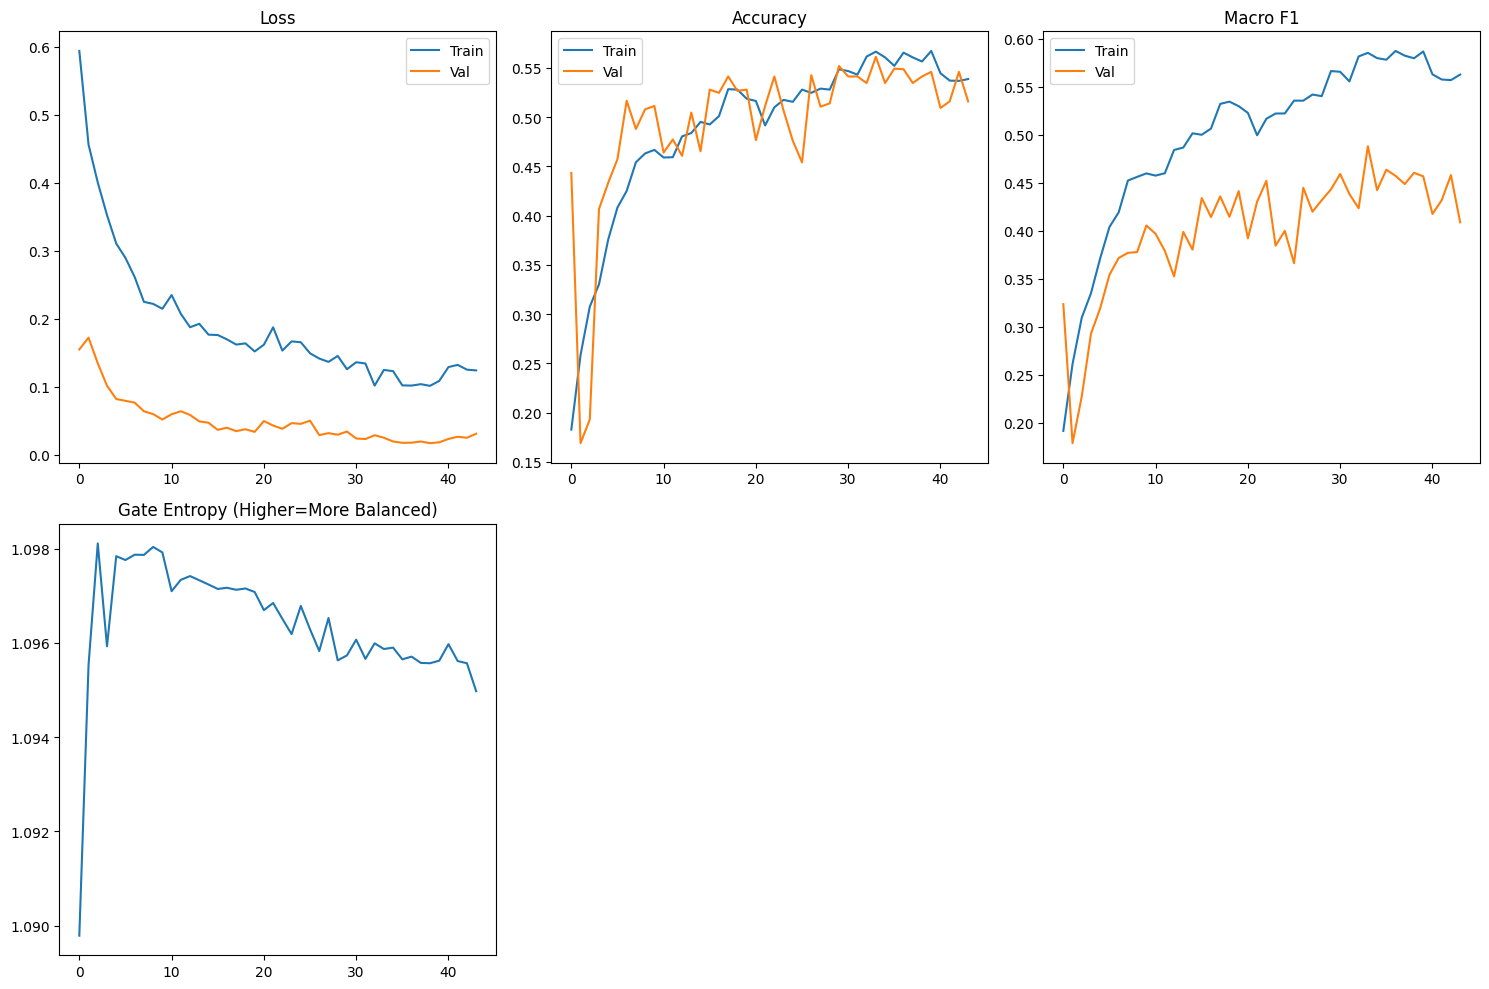


FINAL EVALUATION


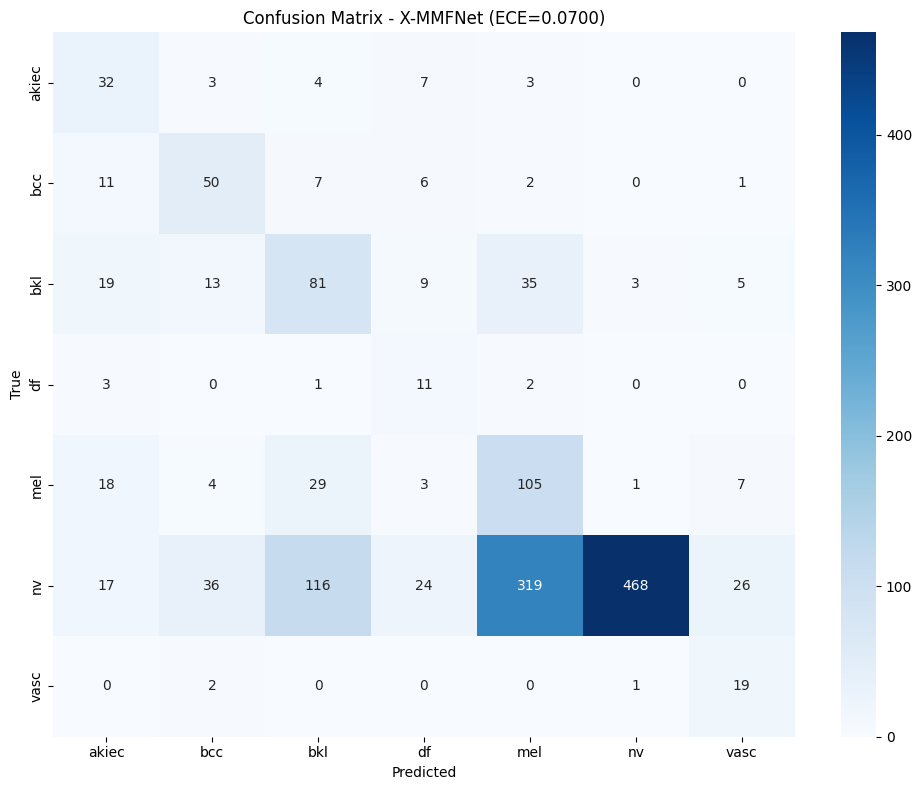


X-MMFNet FINAL TEST RESULTS
Accuracy: 0.5096
Macro F1: 0.4425
Weighted F1: 0.5565
Macro AUC: 0.8939
ECE: 0.0700 (Target < 0.05)
Mean Uncertainty Entropy: 1.1530
High Uncertainty Rate: 83.77% (flagged for review)

Per-class metrics:
  akiec : Precision=0.3200, Recall=0.6531, F1=0.4295
  bcc   : Precision=0.4630, Recall=0.6494, F1=0.5405
  bkl   : Precision=0.3403, Recall=0.4909, F1=0.4020
  df    : Precision=0.1833, Recall=0.6471, F1=0.2857
  mel   : Precision=0.2253, Recall=0.6287, F1=0.3318
  nv    : Precision=0.9894, Recall=0.4652, F1=0.6329
  vasc  : Precision=0.3276, Recall=0.8636, F1=0.4750

Target (beat V4-C): Accuracy >= 0.835, Macro F1 >= 0.733
NEEDS IMPROVEMENT

Generating TMEP dashboard...


RuntimeError: The size of tensor a (32) must match the size of tensor b (56) at non-singleton dimension 1

: 

In [ ]:
# Plot + Test:
trainer.plot_history()
results, robustness = run_final_evaluation(model, test_loader, config, config.SAVE_DIR)